# Credit Risk Prediction using Machine Learning

## Problem Statement

**Goal:** Predict whether a borrower will default on a loan using financial and credit history features.

In [42]:
import kagglehub
import pandas as pd
import os

# Download the dataset from Kaggle Hub
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'credit_risk_dataset.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

print("Data loaded successfully into a DataFrame. Displaying the first 5 rows:")
display(df.head())

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Data loaded successfully into a DataFrame. Displaying the first 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

Missing

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



Value Counts for Categorical Columns:

Value counts for column 'person_home_ownership':


,count
person_home_ownership,
RENT,16446
MORTGAGE,13444
OWN,2584
OTHER,107



Value counts for column 'loan_intent':


...


Value counts for column 'loan_grade':


,count
loan_grade,
A,10777
B,10451
C,6458
D,3626
E,964
F,241
G,64



Value counts for column 'cb_person_default_on_file':


,count
cb_person_default_on_file,
N,26836
Y,5745



Generating Histograms for Numerical Features:


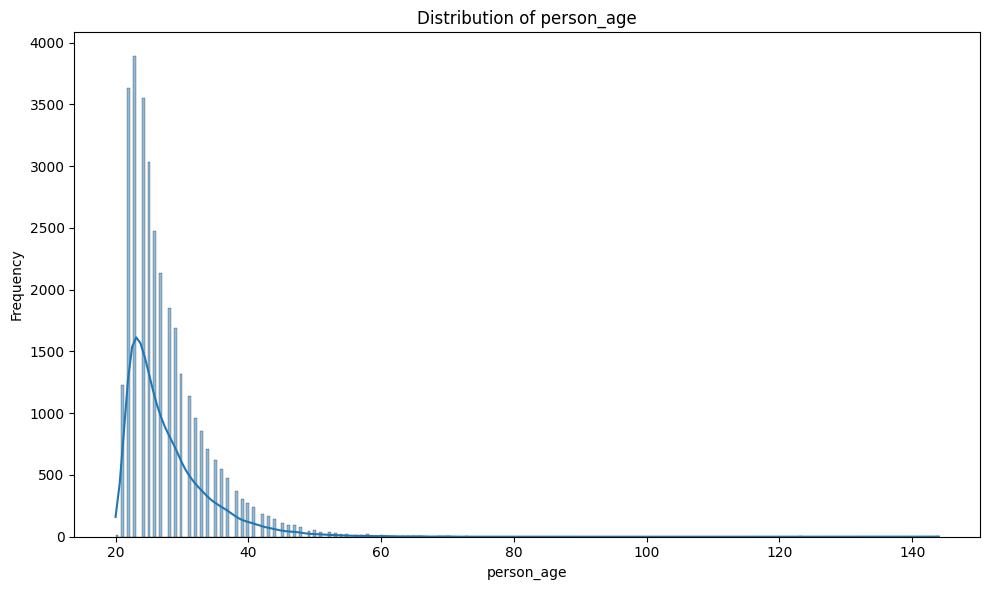

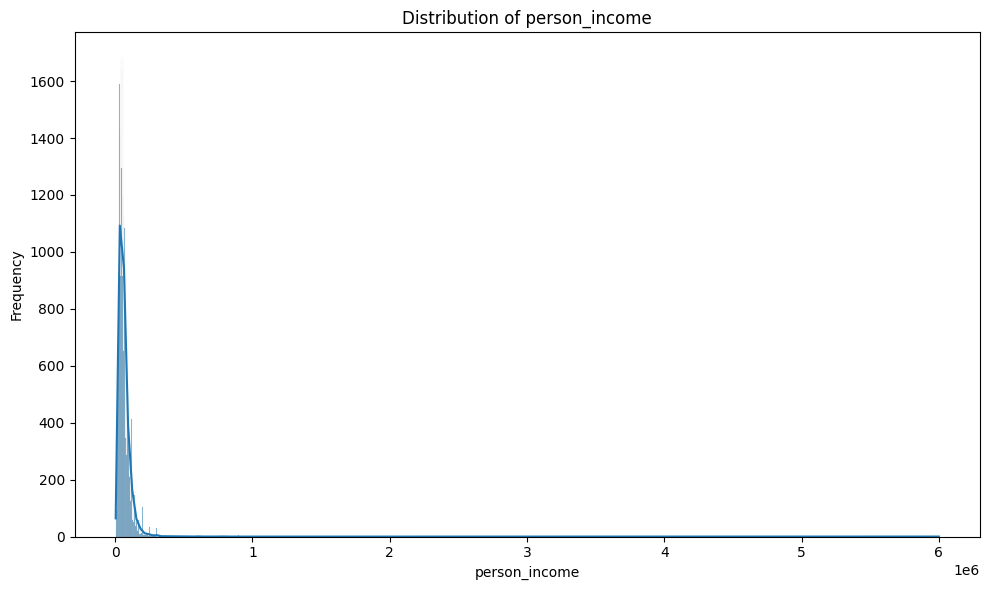

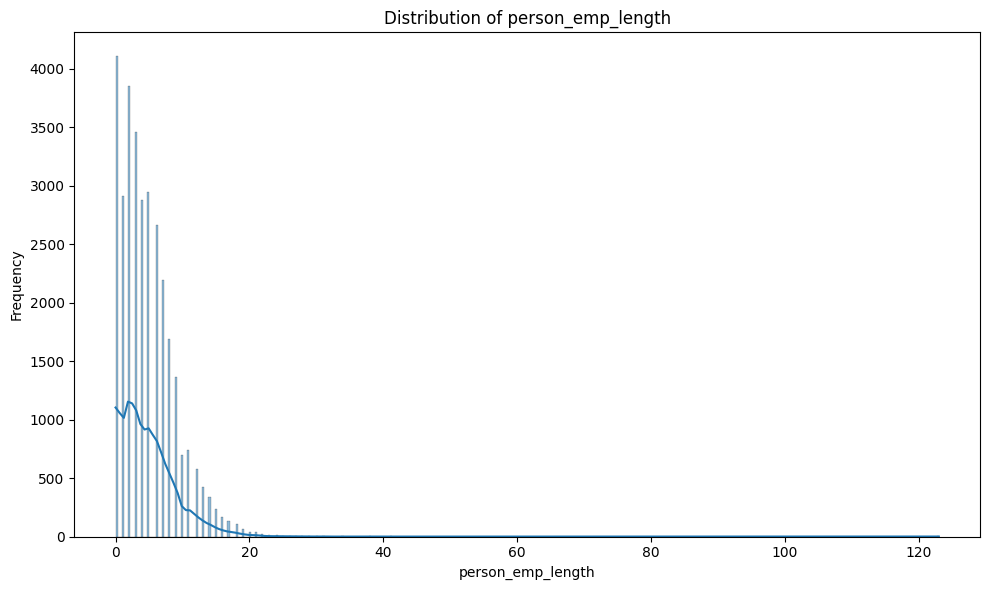

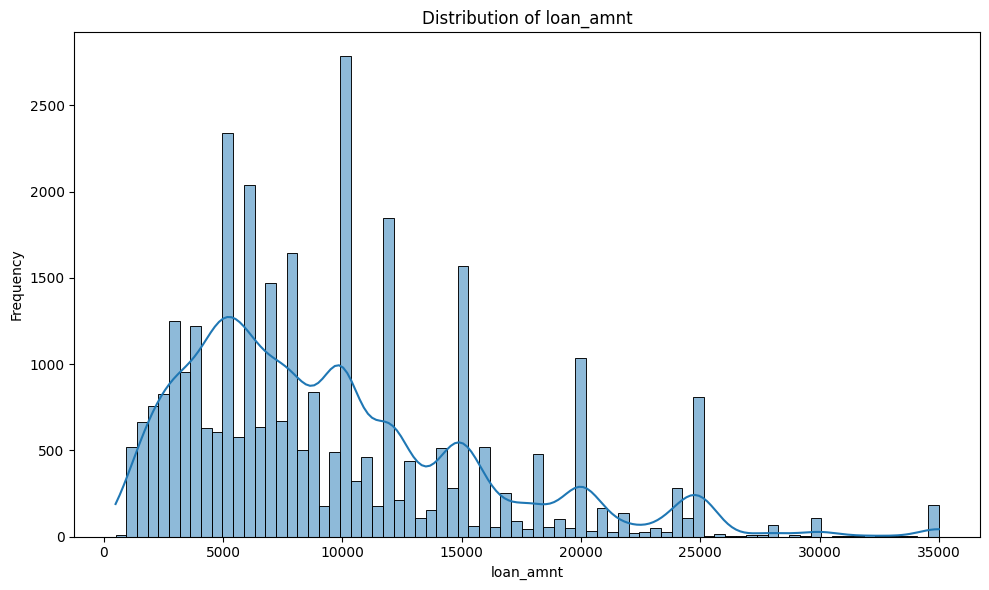

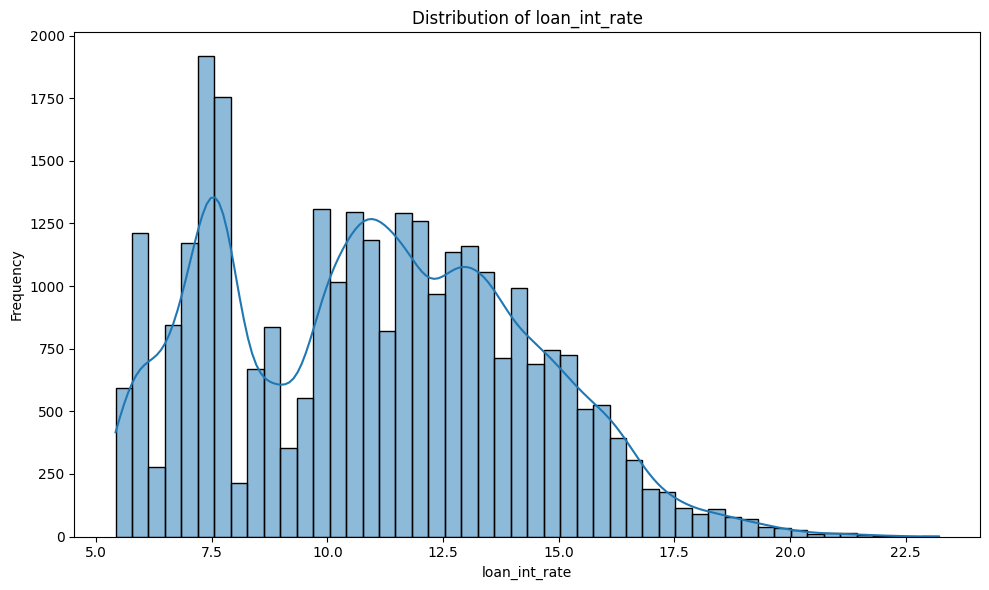

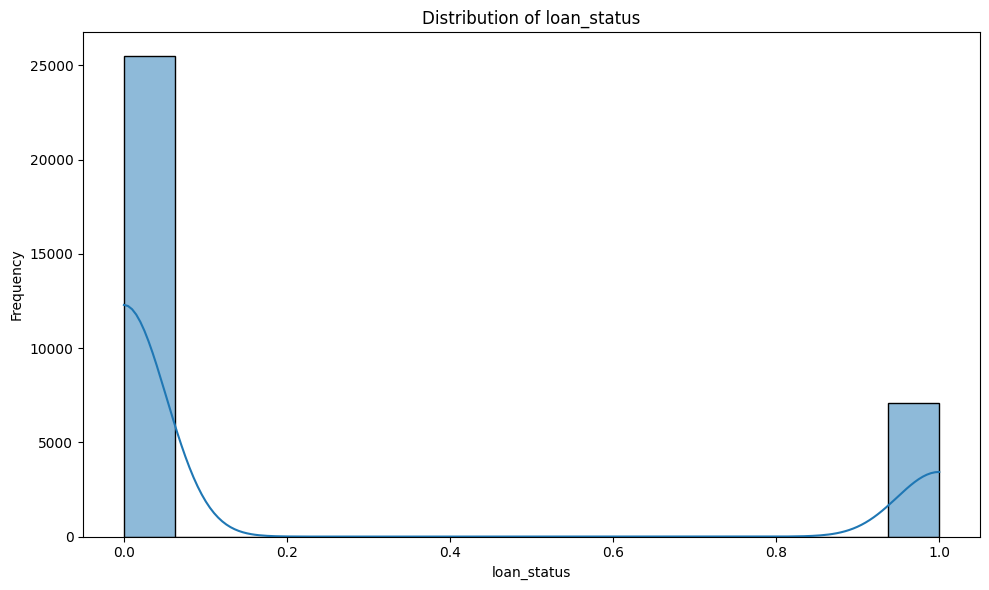

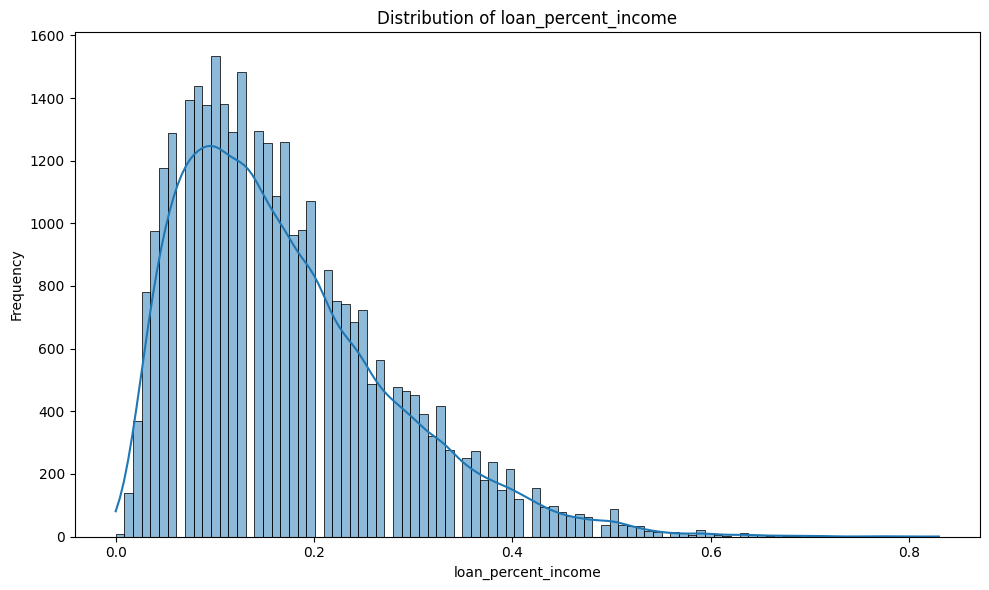

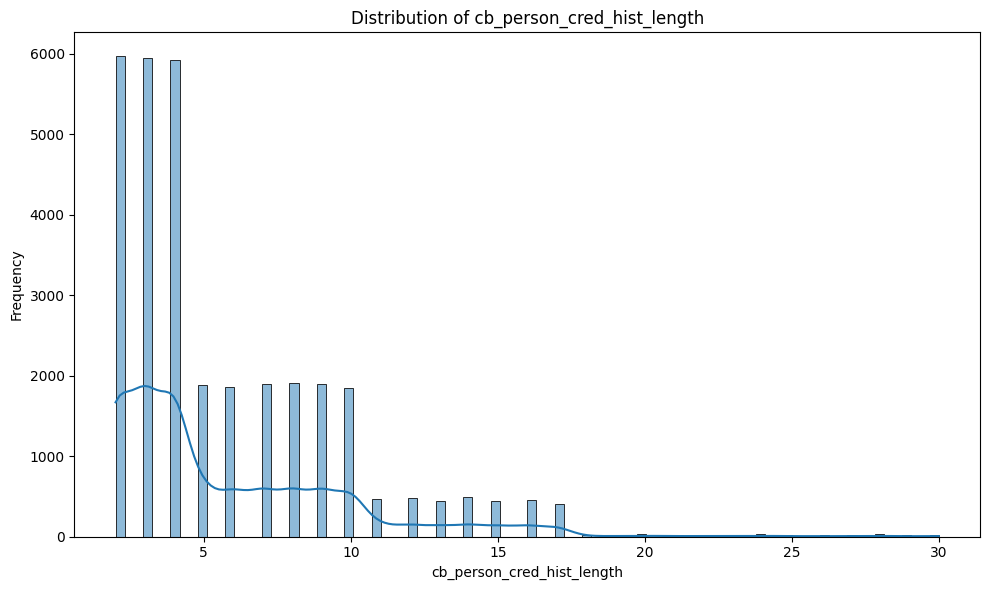


Generating Bar Plots for Categorical Features:


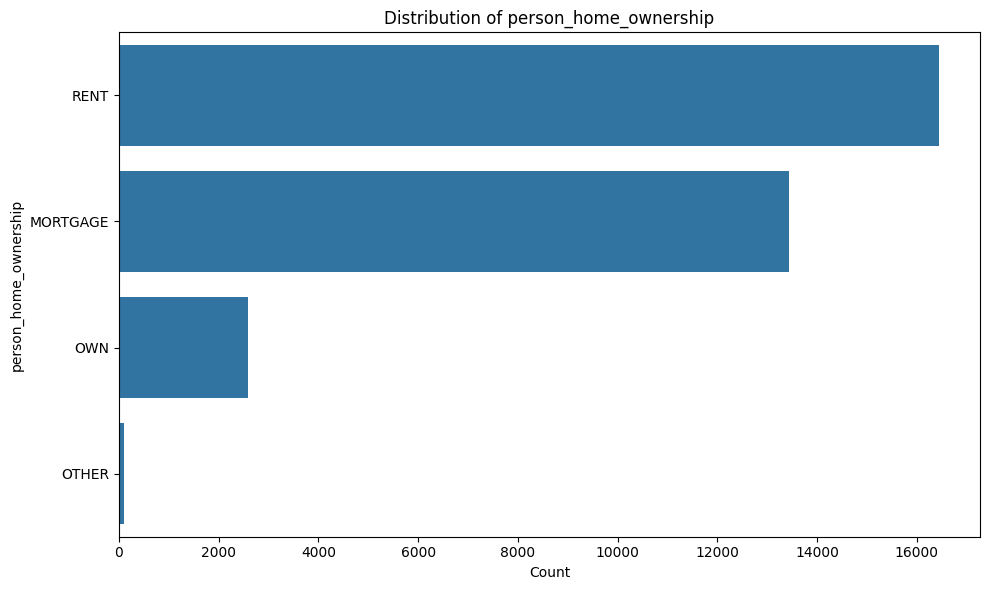

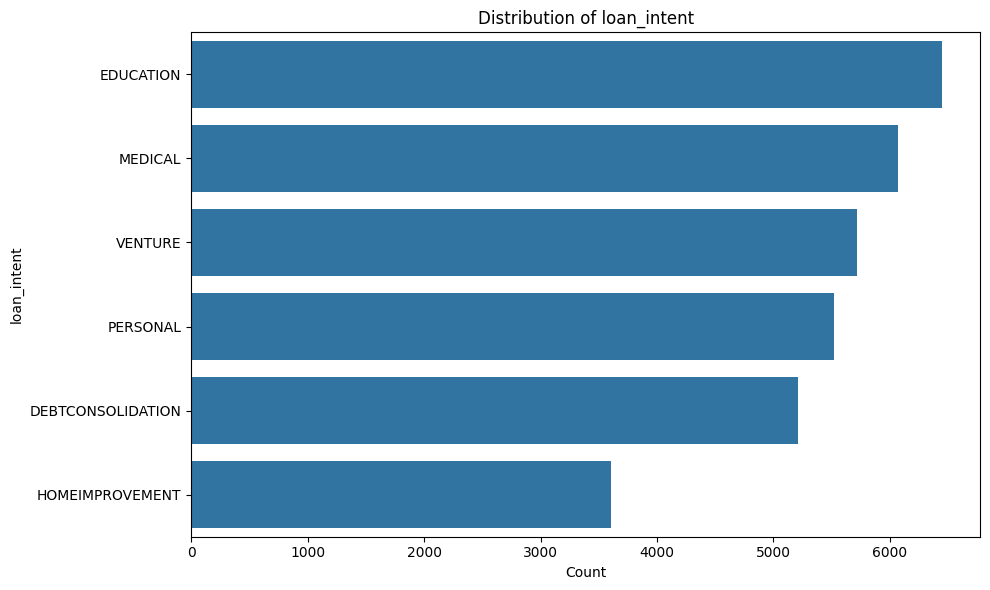

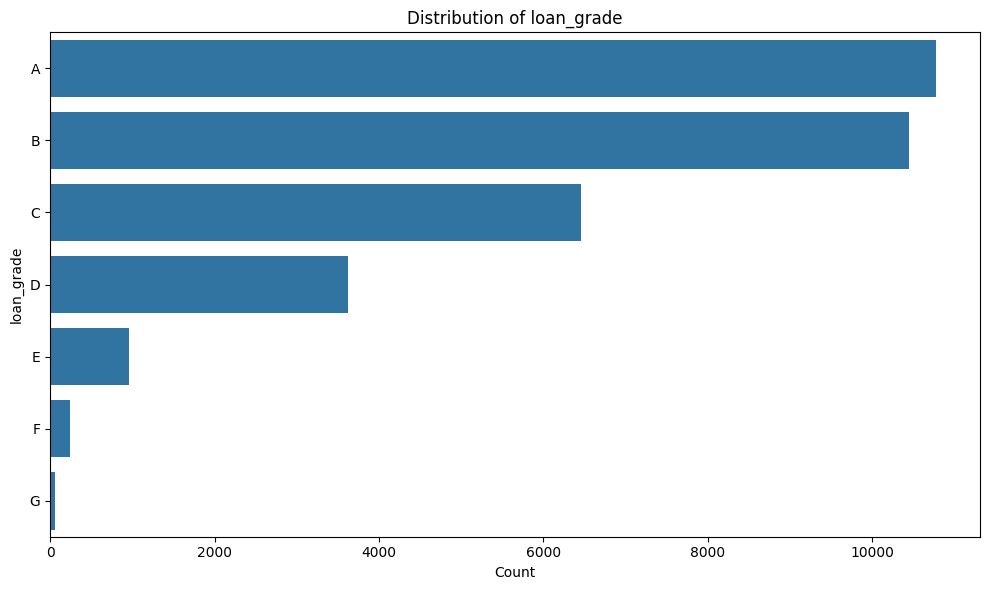

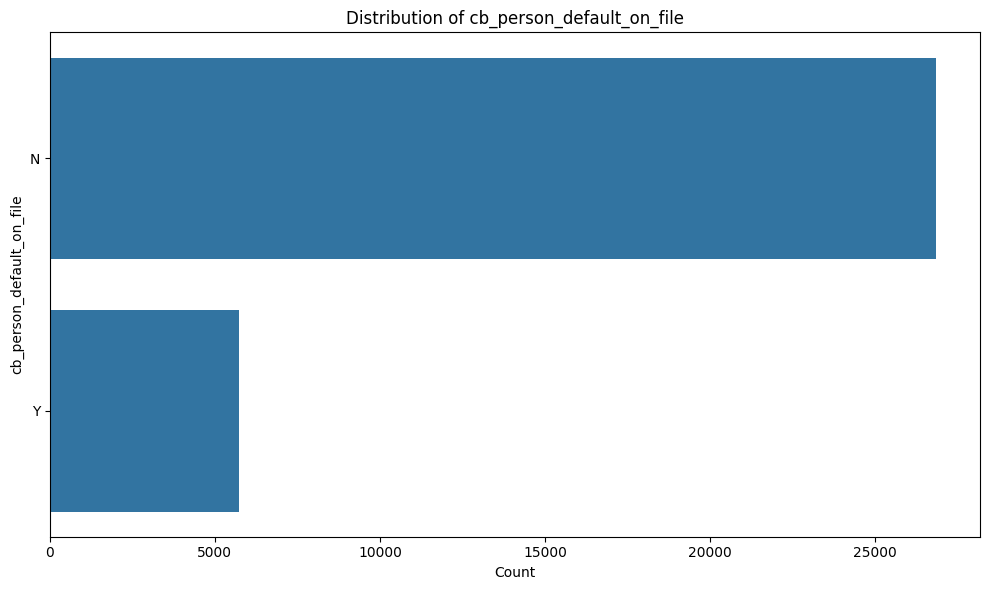

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

print("DataFrame Information:")
df.info()

print("\nMissing Values per Column:")
print(df.isnull().sum())

print("\nDescriptive Statistics for Numerical Columns:")
display(df.describe())

print("\nValue Counts for Categorical Columns:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\nValue counts for column '{col}':")
    display(df[col].value_counts())

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("\nGenerating Histograms for Numerical Features:")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

print("\nGenerating Bar Plots for Categorical Features:")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

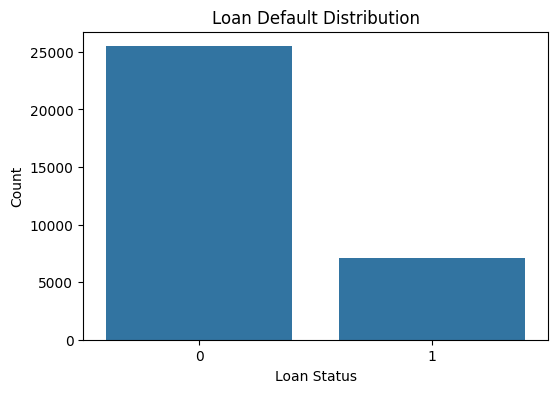

Loan Status Percentage:
loan_status
0    0.782
1    0.218
Name: proportion, dtype: float64


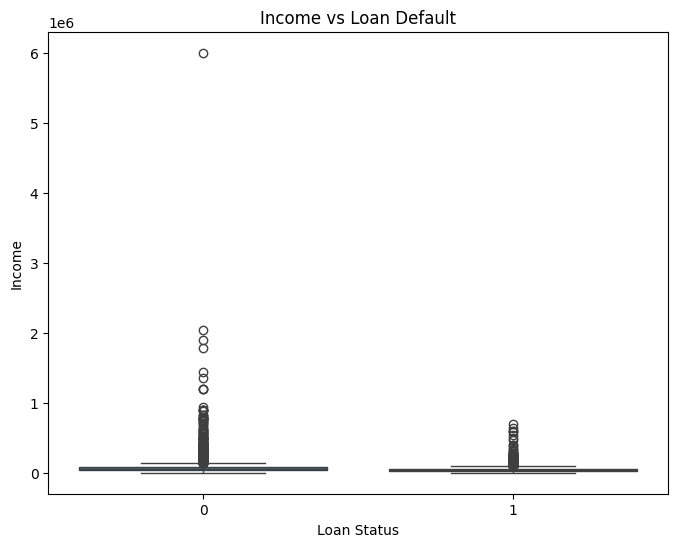

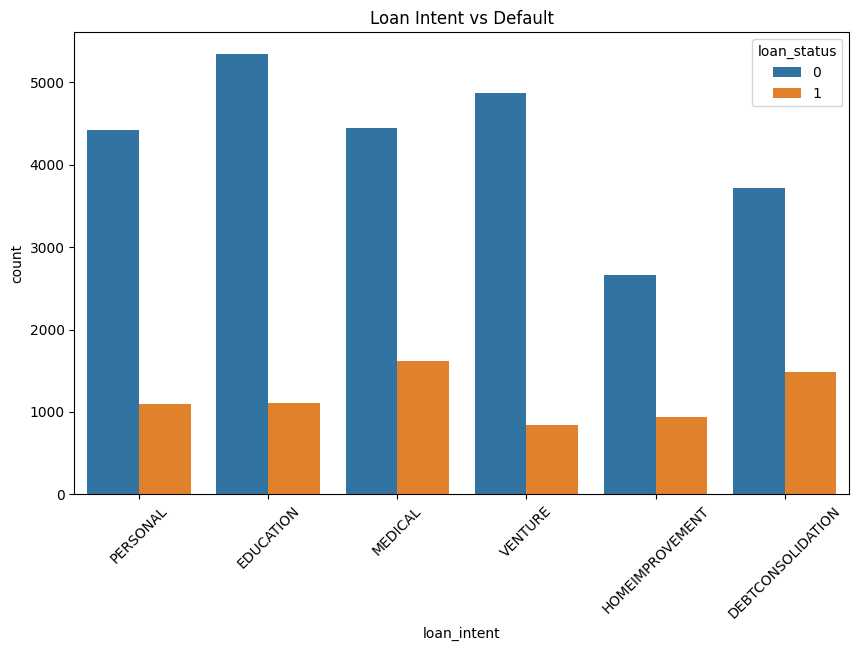

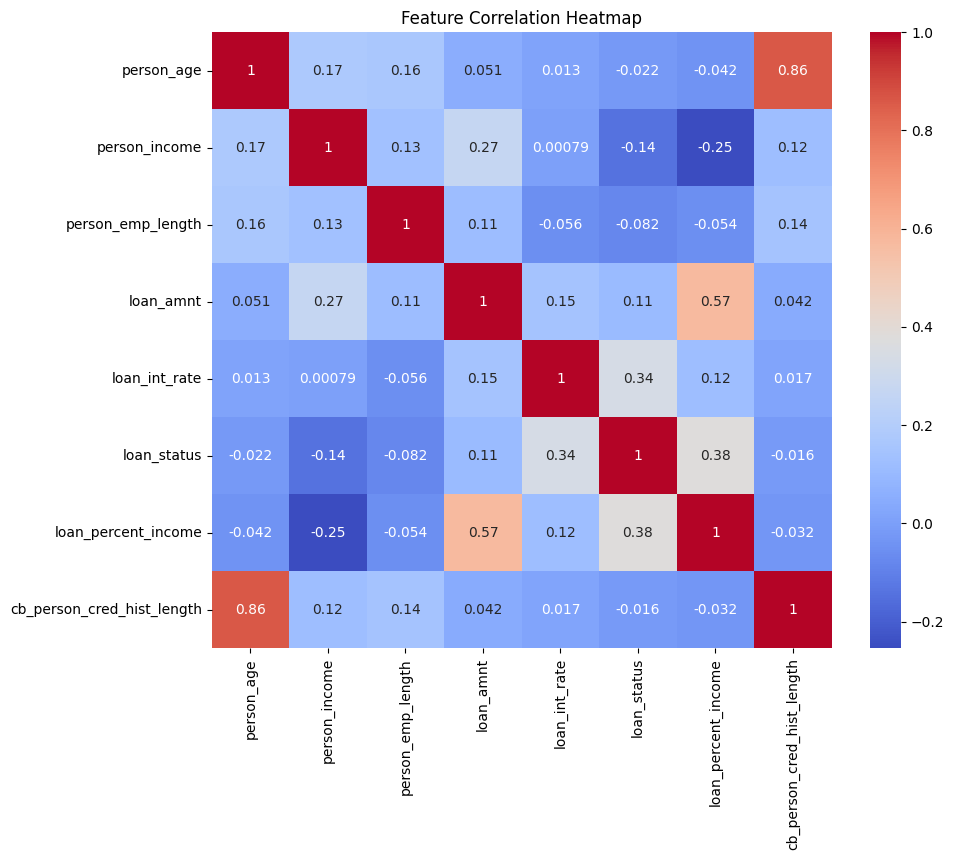


Default Rate by Home Ownership:


loan_status,0,1
person_home_ownership,,
MORTGAGE,0.874293,0.125707
OTHER,0.691589,0.308411
OWN,0.925310,0.074690
RENT,0.684300,0.315700


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(6,4))
sns.countplot(x=df["loan_status"])
plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()
print("Loan Status Percentage:")
print(df["loan_status"].value_counts(normalize=True).round(3))

# INCOME VS DEFAULT
plt.figure(figsize=(8,6))
sns.boxplot(x="loan_status", y="person_income", data=df)
plt.title("Income vs Loan Default")
plt.xlabel("Loan Status")
plt.ylabel("Income")
plt.show()

# LOAN INTENT VS DEFAULT
plt.figure(figsize=(10,6))
sns.countplot(x="loan_intent", hue="loan_status", data=df)
plt.title("Loan Intent vs Default")
plt.xticks(rotation=45)
plt.show()

# CORRELATION HEATMAP

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# HOME OWNERSHIP VS DEFAULT RATE
print("\nDefault Rate by Home Ownership:")
display(pd.crosstab(df["person_home_ownership"], df["loan_status"], normalize="index"))

In [48]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score
)

# ----------------------------
# 1) Split FIRST (prevents leakage)
# ----------------------------
target_col = "loan_status"
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# 2) Feature engineering BEFORE scaling
#    Add credit_history_to_age_ratio safely
# ----------------------------
def add_ratio_feature(X_df: pd.DataFrame) -> pd.DataFrame:
    X_df = X_df.copy()

    # cap age to avoid extreme outliers (same idea as your code)
    if "person_age" in X_df.columns:
        X_df["person_age"] = X_df["person_age"].clip(upper=100)

    if "person_emp_length" in X_df.columns:
        X_df["person_emp_length"] = X_df["person_emp_length"].clip(upper=60)

    # safe ratio: avoid divide-by-zero
    if "cb_person_cred_hist_length" in X_df.columns and "person_age" in X_df.columns:
        denom = X_df["person_age"].replace(0, np.nan)
        X_df["credit_history_to_age_ratio"] = (X_df["cb_person_cred_hist_length"] / denom).fillna(0.0)

    return X_df

# Set feature_names_out to None since we are adding a new feature
fe = FunctionTransformer(add_ratio_feature, feature_names_out=None)

# ----------------------------
# 3) Column types
# ----------------------------
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# After feature engineering, 'credit_history_to_age_ratio' will be a new numerical feature
# It needs to be explicitly added to numeric_features for the ColumnTransformer to handle it.
# Apply the feature engineering to a dummy X_train to get the updated column list
dummy_X_train_transformed = fe.transform(X_train)
# Get updated numerical features by selecting dtypes from the transformed dummy dataframe
numeric_features = dummy_X_train_transformed.select_dtypes(include=["int64", "float64"]).columns.tolist()

# ----------------------------
# 4) Preprocessing pipelines
# ----------------------------
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

# ----------------------------
# 5) Model pipelines
# ----------------------------
logit_pipe = Pipeline(steps=[
    ("fe", fe),
    ("preprocess", preprocess),
    ("model", LogisticRegression(random_state=42, max_iter=2000))
])

rf_pipe = Pipeline(steps=[
    ("fe", fe),
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42, n_estimators=400, n_jobs=-1))
])

# ----------------------------
# 6) Fit + evaluate helper
# ----------------------------
def evaluate(model, X_te, y_te, name="model"):
    y_pred = model.predict(X_te)
    # Some models expose predict_proba; use it for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
        roc = roc_auc_score(y_te, y_prob)
    else:
        roc = None

    print(f"\n===== {name} =====")
    print(f"Accuracy: {accuracy_score(y_te, y_pred):.4f}")
    print(f"F1:       {f1_score(y_te, y_pred):.4f}")
    if roc is not None:
        print(f"ROC-AUC:  {roc:.4f}")
    print("\nClassification report:")
    print(classification_report(y_te, y_pred))

# ----------------------------
# 7) Baseline models
# ----------------------------
print("Training baseline Logistic Regression...")
logit_pipe.fit(X_train, y_train)
evaluate(logit_pipe, X_test, y_test, "Logistic Regression (baseline)")

print("Training baseline Random Forest...")
rf_pipe.fit(X_train, y_train)
evaluate(rf_pipe, X_test, y_test, "Random Forest (baseline)")

# ----------------------------
# 8) Tune Logistic Regression (no leakage)
# ----------------------------
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    # if you want recall-heavy behavior, add class_weight
    "model__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=logit_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("\nTuning Logistic Regression...")
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_logit = grid.best_estimator_
evaluate(best_logit, X_test, y_test, "Logistic Regression (tuned)")

Training baseline Logistic Regression...

===== Logistic Regression (baseline) =====
Accuracy: 0.8683
F1:       0.6521
ROC-AUC:  0.8694

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.57      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.79      6517
weighted avg       0.86      0.87      0.86      6517

Training baseline Random Forest...

===== Random Forest (baseline) =====
Accuracy: 0.9329
F1:       0.8224
ROC-AUC:  0.9314

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.94      0.93      0.93      6517


Tuning Logistic Regression...
Best pa

In [49]:
import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report
import pandas as pd

y_prob = rf_pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)
rows = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    rows.append({
        "threshold": t,
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"],
        "accuracy": report["accuracy"]
    })

results = pd.DataFrame(rows).sort_values("f1_1", ascending=False)
display(results)

best_t = results.iloc[0]["threshold"]
print("Best threshold by F1 for class 1:", best_t)

y_pred_best = (y_prob >= best_t).astype(int)
print("\nClassification report at best threshold:")
print(classification_report(y_test, y_pred_best))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_best))

,threshold,precision_1,recall_1,f1_1,accuracy
9,0.55,0.986315,0.709564,0.825358,0.934479
8,0.50,0.974013,0.711674,0.822430,0.932945
7,0.45,0.958763,0.719409,0.822017,0.932024
10,0.60,0.990070,0.701125,0.820914,0.933251
6,0.40,0.930481,0.734177,0.820755,0.930029
11,0.65,0.989980,0.694796,0.816529,0.931870
5,0.35,0.894781,0.747539,0.814559,0.925733
12,0.70,0.992813,0.680028,0.807179,0.929108
4,0.30,0.839478,0.768636,0.802496,0.917447
13,0.75,0.995785,0.664557,0.797132,0.926193


Best threshold by F1 for class 1: 0.5500000000000002

Classification report at best threshold:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5095
           1       0.99      0.71      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.96      0.85      0.89      6517
weighted avg       0.94      0.93      0.93      6517


Confusion matrix:
[[5081   14]
 [ 413 1009]]


,feature,importance
5,loan_percent_income,0.219801
1,person_income,0.136039
4,loan_int_rate,0.107518
3,loan_amnt,0.069617
2,person_emp_length,0.056716
21,loan_grade_D,0.052500
11,person_home_ownership_RENT,0.052470
7,credit_history_to_age_ratio,0.042169
0,person_age,0.037947
8,person_home_ownership_MORTGAGE,0.027382


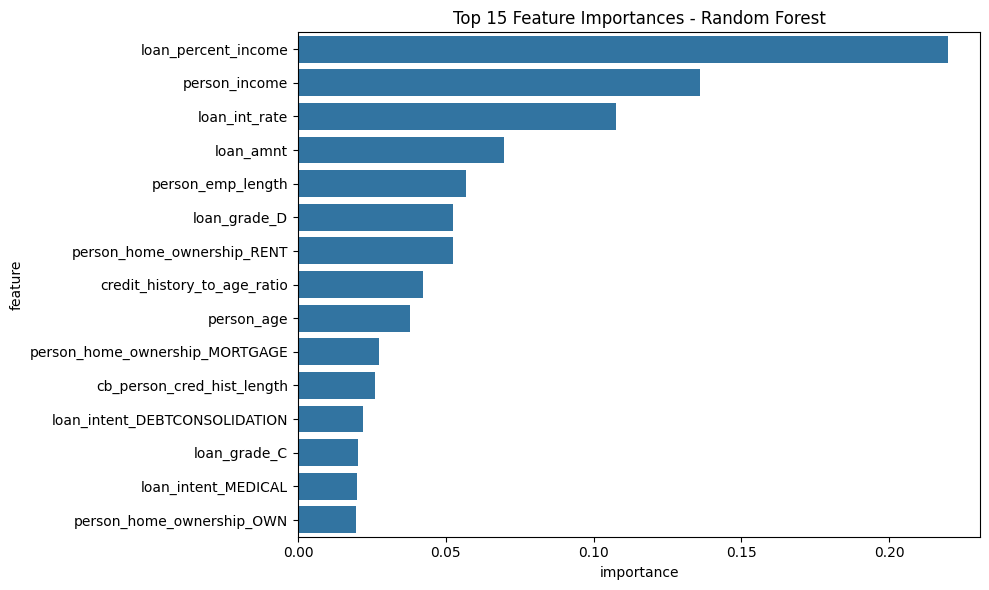

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ohe = rf_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = np.r_[numeric_features, cat_feature_names]
importances = rf_pipe.named_steps["model"].feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

display(fi.head(20))

plt.figure(figsize=(10,6))
sns.barplot(data=fi.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

##  Business Interpretation

---



*   **Best Model Performance:** The Random Forest model achieved the best performance with an ROC-AUC of 0.93.

*   **Most Important Predictors:** The most important predictors were `loan_percent_income`, `person_income`, and `loan_int_rate`.

*   **Business Interpretation:** This suggests that borrowers with a higher loan burden relative to their income are more likely to default. Therefore, a careful assessment of an applicant's income and existing debt obligations, particularly the percentage of income dedicated to loan repayment, is crucial for effective credit risk management.